# NOARK Position Reconstruction & Comparison Analysis

This notebook reconstructs the NOARK position from two independent sources:
1. **Camera (Ground Truth):** Using ArUco marker `tvec` / `rvec` → table-frame position via the same pipeline as `camera_pose.py`
2. **Encoder (Kinematics):** Using circle–circle intersection from cable lengths, as implemented in `nkin.py`

Then it compares both to visualise tracking accuracy.

---
### File Assumptions
| File | Produced by | Key columns |
|------|------------|-------------|
| `camera_data.csv` | `Cam_Data_log.py` | `timestamp`, `tvec_12_x/y/z`, `tvec_14_x/y/z`, `tvec_20_x/y/z`, `rvec_12_x/y/z`, ... |
| `sensor_data.csv` | `Enc_Data_log.py` | `timestamp`, `Millis`, `enc1`, `enc2` |

## Step 0 — Imports & Config

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import sqrt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# 1. Robust path detection (Works in Notebooks AND Scripts)
try:
    repo_root = Path(__file__).parent.absolute()
except NameError:
    repo_root = Path.cwd().absolute()

# 2. Update File paths using the / operator (cross-platform)
CAM_CSV = repo_root/"recordings"/ "linear_t2" / "camera_data.csv"
ENC_CSV = repo_root / "recordings" / "linear_t2" / "sensor_data.csv"
print(f"Repo Root: {repo_root}")
# 3. Update Calibration paths to be relative to repo_root
CAM_CALIB_PATH   = repo_root / "notebooks" / "calibration" / "output" / "good.toml"
TABLE_CALIB_PATH = repo_root / "estimator" / "charuco_pose" / "charuco_pose.toml"

# ── Kinematics constants (from nkin.py) ──────────────────────────────────────
P2 = np.array([-0.495, 0, -0.027])   # Left upper pulley
P4 = np.array([ 0.495, 0, -0.027])   # Right upper pulley

r_ML = r_MR = 0.033   # Motor spool radius (m)

# ── Marker config (from camera_pose.py) ──────────────────────────────────────
MARKER_LENGTH = 0.049  # metres
MARKER_IDS    = [12, 14, 20]
MARKER_OFFSETS = {
    12: np.array([0,      0,  -0.055]),
    14: np.array([-0.126, 0,  -0.054]),
    20: np.array([ 0.126, 0,  -0.054]),
}

print("Config loaded ✓")

Repo Root: e:\Ragav\MS Bio Engineering\NOARK_backbone
Config loaded ✓


---
## Step 1 — Load the CSVs

In [2]:
# ── Camera CSV ────────────────────────────────────────────────────────────────
cam_df = pd.read_csv(CAM_CSV, parse_dates=["timestamp"])
print(f"Camera CSV: {len(cam_df)} rows")
cam_df.head(3)

Camera CSV: 1132 rows


,timestamp,sync_pin,tvec_12_x,tvec_12_y,tvec_12_z,tvec_14_x,tvec_14_y,tvec_14_z,tvec_20_x,tvec_20_y,tvec_20_z,rvec_12_x,rvec_12_y,rvec_12_z,rvec_14_x,rvec_14_y,rvec_14_z,rvec_20_x,rvec_20_y,rvec_20_z
0,2026-04-23 11:49:39.157110,0,0.240277,-0.045530,0.432007,NaN,NaN,NaN,NaN,NaN,NaN,-3.113738,0.007525,-0.094086,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-23 11:49:39.195178,0,0.240229,-0.045525,0.431928,NaN,NaN,NaN,NaN,NaN,NaN,-3.115932,0.007867,-0.096541,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-23 11:49:39.236591,0,0.240262,-0.045527,0.431954,NaN,NaN,NaN,NaN,NaN,NaN,-3.115230,0.007747,-0.095778,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── Encoder CSV ───────────────────────────────────────────────────────────────
enc_df = pd.read_csv(ENC_CSV, parse_dates=["timestamp"])
print(f"Encoder CSV: {len(enc_df)} rows")
enc_df.head(3)

Encoder CSV: 11539 rows


,timestamp,Millis,enc1,enc2
0,2026-04-23 11:49:39.127084,20997.77,0.02,-0.01
1,2026-04-23 11:49:39.129123,20999.80,0.02,-0.01
2,2026-04-23 11:49:39.131125,21001.80,0.02,-0.01


In [4]:
# ── Session overlap check ─────────────────────────────────────────────────────
print(f"Camera start : {cam_df['timestamp'].iloc[0]}")
print(f"Camera end   : {cam_df['timestamp'].iloc[-1]}")
print(f"Encoder start: {enc_df['timestamp'].iloc[0]}")
print(f"Encoder end  : {enc_df['timestamp'].iloc[-1]}")

overlap_start = max(cam_df['timestamp'].iloc[0], enc_df['timestamp'].iloc[0])
overlap_end   = min(cam_df['timestamp'].iloc[-1], enc_df['timestamp'].iloc[-1])
# ── Debug: inspect raw timestamps ────────────────────────────────────────────
print("=== RAW TIMESTAMP INSPECTION ===")
print(f"\ncam_df['timestamp'] dtype : {cam_df['timestamp'].dtype}")
print(f"enc_df['timestamp'] dtype : {enc_df['timestamp'].dtype}")

print(f"\nCamera    first 3 : {cam_df['timestamp'].head(3).tolist()}")
print(f"Camera    last  3 : {cam_df['timestamp'].tail(3).tolist()}")
print(f"Encoder   first 3 : {enc_df['timestamp'].head(3).tolist()}")
print(f"Encoder   last  3 : {enc_df['timestamp'].tail(3).tolist()}")

print(f"\nCamera  range : {cam_df['timestamp'].iloc[0]}  →  {cam_df['timestamp'].iloc[-1]}")
print(f"Encoder range : {enc_df['timestamp'].iloc[0]}  →  {enc_df['timestamp'].iloc[-1]}")

if overlap_start >= overlap_end:
    raise RuntimeError("NO OVERLAP — CSVs are from different sessions!")

print(f"\nOverlap duration: {(overlap_end - overlap_start).total_seconds():.1f}s")

# ── Encoder must start before or at camera start ──────────────────────────────
lead = (cam_df['timestamp'].iloc[0] - enc_df['timestamp'].iloc[0]).total_seconds()
if lead < 0:
    print(f"Camera started {abs(lead):.3f}s BEFORE encoder — init position may be wrong!")
else:
    print(f"Encoder leads camera by {lead:.3f}s — init position is safe")

Camera start : 2026-04-23 11:49:39.157110
Camera end   : 2026-04-23 11:50:02.275709
Encoder start: 2026-04-23 11:49:39.127084
Encoder end  : 2026-04-23 11:50:02.279264
=== RAW TIMESTAMP INSPECTION ===

cam_df['timestamp'] dtype : datetime64[us]
enc_df['timestamp'] dtype : datetime64[us]

Camera    first 3 : [Timestamp('2026-04-23 11:49:39.157110'), Timestamp('2026-04-23 11:49:39.195178'), Timestamp('2026-04-23 11:49:39.236591')]
Camera    last  3 : [Timestamp('2026-04-23 11:50:02.237927'), Timestamp('2026-04-23 11:50:02.258187'), Timestamp('2026-04-23 11:50:02.275709')]
Encoder   first 3 : [Timestamp('2026-04-23 11:49:39.127084'), Timestamp('2026-04-23 11:49:39.129123'), Timestamp('2026-04-23 11:49:39.131125')]
Encoder   last  3 : [Timestamp('2026-04-23 11:50:02.276014'), Timestamp('2026-04-23 11:50:02.277291'), Timestamp('2026-04-23 11:50:02.279264')]

Camera  range : 2026-04-23 11:49:39.157110  →  2026-04-23 11:50:02.275709
Encoder range : 2026-04-23 11:49:39.127084  →  2026-04-23 11

---
## Step 2 — Load Camera Calibration & Build Helpers

In [5]:
import toml

# ── Load table reference frame only ──────────────────────────────────────────
tbl     = toml.load(TABLE_CALIB_PATH)
R_table = np.array(tbl["rotation_matrix"]).reshape(3, 3)
T_table = np.array(tbl["tvec"]).reshape(3, 1)

# Sanity checks
assert R_table.shape == (3, 3), f"R_table wrong shape: {R_table.shape}"
assert T_table.shape == (3, 1), f"T_table wrong shape: {T_table.shape}"

print("Table rotation R:")
print(np.round(R_table, 4))
print("\nTable translation T (m):", T_table.flatten().round(4))
print("\nShapes OK ✓")

Table rotation R:
[[-0.9995  0.0118 -0.0301]
 [-0.0117 -0.9999 -0.0028]
 [-0.0301 -0.0024  0.9995]]

Table translation T (m): [-0.0232 -0.0173  0.6735]

Shapes OK ✓


---
## Step 3 — Reconstruct NOARK Position from Camera Data

For each frame we:
1. Take the raw `tvec` / `rvec` for each detected marker (already stored by `Cam_Data_log.py`)
2. Apply the marker-specific physical offset to get the handle position in camera frame
3. Average all available marker positions → **centroid in camera frame**
4. Transform to **table frame**: `P_table = R_table.T @ (P_cam - T_table)`

In [6]:
# ── Data sanity check ─────────────────────────────────────────────────────────
print("Shape:", cam_df.shape)

print("\n--- NaN counts per marker ---")
for mid in [12, 14, 20]:
    col = f'tvec_{mid}_x'
    print(f"Marker {mid} NaN rows: {cam_df[col].isna().sum()} / {len(cam_df)}")

print("\n--- Rows where ALL 3 markers missing ---")
all_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().all(axis=1)
print(f"Count: {all_missing.sum()}")

print("\n--- Rows where ANY marker missing ---")
any_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().any(axis=1)
print(f"Count: {any_missing.sum()}")

print("\n--- Sample of raw tvec values (first 10 rows) ---")
print(cam_df[['timestamp','tvec_12_x','tvec_14_x','tvec_20_x']].head(10).to_string())

Shape: (1132, 20)

--- NaN counts per marker ---
Marker 12 NaN rows: 66 / 1132
Marker 14 NaN rows: 1085 / 1132
Marker 20 NaN rows: 1042 / 1132

--- Rows where ALL 3 markers missing ---
Count: 20

--- Rows where ANY marker missing ---
Count: 1132

--- Sample of raw tvec values (first 10 rows) ---
                   timestamp  tvec_12_x  tvec_14_x  tvec_20_x
0 2026-04-23 11:49:39.157110   0.240277        NaN        NaN
1 2026-04-23 11:49:39.195178   0.240229        NaN        NaN
2 2026-04-23 11:49:39.236591   0.240262        NaN        NaN
3 2026-04-23 11:49:39.276659   0.240299        NaN        NaN
4 2026-04-23 11:49:39.309794   0.240279        NaN        NaN
5 2026-04-23 11:49:39.337165   0.240298        NaN        NaN
6 2026-04-23 11:49:39.359539   0.240369        NaN        NaN
7 2026-04-23 11:49:39.380700   0.240335        NaN        NaN
8 2026-04-23 11:49:39.403558   0.240369        NaN        NaN
9 2026-04-23 11:49:39.424920   0.240343        NaN        NaN


In [7]:
def get_centroid_cam(row, marker_ids=MARKER_IDS, offsets=MARKER_OFFSETS):
    """
    Replicates camera_pose.py::_get_centroid().
    Returns centroid in CAMERA frame as (3,1), or None if no marker visible.
    """
    points = []
    for mid in marker_ids:
        tvec_cols = [f"tvec_{mid}_x", f"tvec_{mid}_y", f"tvec_{mid}_z"]
        rvec_cols = [f"rvec_{mid}_x", f"rvec_{mid}_y", f"rvec_{mid}_z"]
        tvec = row[tvec_cols].values.astype(float)
        rvec = row[rvec_cols].values.astype(float)
        if np.any(np.isnan(tvec)) or np.any(np.isnan(rvec)):
            continue
        R_marker, _ = cv2.Rodrigues(rvec)
        offset = offsets[mid].reshape(3, 1)
        pos_cam = R_marker @ offset + tvec.reshape(3, 1)
        points.append(pos_cam.flatten())
    if not points:
        return None
    return np.mean(points, axis=0).reshape(3, 1)


def cam_to_table(p_cam, R_table=R_table, T_table=T_table):
    """
    Replicates camera_pose.py::_get_local_coordinates().
    P_table = R_table.T @ (P_cam - T_table)
    """
    return (R_table.T @ (p_cam - T_table)).flatten()


# Apply row-wise
results = []
for _, row in cam_df.iterrows():
    p_cam = get_centroid_cam(row)
    if p_cam is None:
        results.append([np.nan, np.nan, np.nan])
    else:
        results.append(cam_to_table(p_cam))

pos_cam = pd.DataFrame(results, columns=["x_cam", "y_cam", "z_cam"])
cam_df  = pd.concat([cam_df.reset_index(drop=True), pos_cam], axis=1)


In [8]:
cam_df.columns

Index(['timestamp', 'sync_pin', 'tvec_12_x', 'tvec_12_y', 'tvec_12_z',
       'tvec_14_x', 'tvec_14_y', 'tvec_14_z', 'tvec_20_x', 'tvec_20_y',
       'tvec_20_z', 'rvec_12_x', 'rvec_12_y', 'rvec_12_z', 'rvec_14_x',
       'rvec_14_y', 'rvec_14_z', 'rvec_20_x', 'rvec_20_y', 'rvec_20_z',
       'x_cam', 'y_cam', 'z_cam'],
      dtype='str')

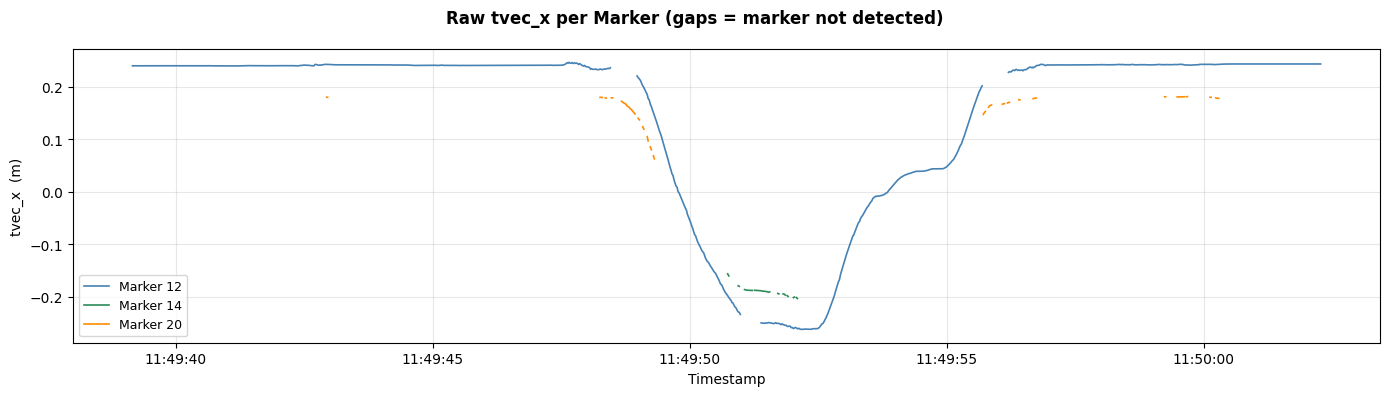

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Raw tvec_x per Marker (gaps = marker not detected)", fontsize=12, fontweight="bold")

marker_cfg = [
    ("tvec_12_x", "steelblue",  "Marker 12"),
    ("tvec_14_x", "seagreen",   "Marker 14"),
    ("tvec_20_x", "darkorange", "Marker 20"),
]

for col, color, label in marker_cfg:
    # True line break where marker not detected — no separate detected_* column needed
    y = np.where(cam_df[col].notna(), cam_df[col].values.astype(float), np.nan)
    ax.plot(cam_df["timestamp"], y, lw=1.2, color=color, label=label)

ax.set_xlabel("Timestamp", fontsize=10)
ax.set_ylabel("tvec_x  (m)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# plt.plot(cam_df['timestamp'], cam_df['tvec_12_x'], label='x_cam')
# plt.plot(cam_df['timestamp'], cam_df['tvec_14_x'], label='x_cam')
# plt.plot(cam_df['timestamp'], cam_df['tvec_20_x'], label='x_cam')

---
## Step 4 — Reconstruct NOARK Position from Encoder Data

Replicates the kinematics in `nkin.py`:
1. At the **zero event** (first encoder row), capture camera-derived free lengths `P2_to_NOARK_init` and `P4_to_NOARK_init`
2. For each encoder tick: `L_free_L = init_L + r_ML * deg2rad(enc1)`, `L_free_R = init_R - r_MR * deg2rad(enc2)`
3. Solve **circle–circle intersection** between `P2` (radius `L_free_L`) and `P4` (radius `L_free_R`) to get `(x, z)` in table frame

In [11]:
# ── Step 4a: Find the zero-reference camera position ─────────────────────────
init_row = cam_df.iloc[0]  # first camera frame — no dropna needed
N0 = np.array([init_row["x_cam"], 0, init_row["z_cam"]])
print(N0)
P2_to_NOARK_init = sqrt((N0[0] - P2[0])**2 + (N0[2] - P2[2])**2)
P4_to_NOARK_init = sqrt((N0[0] - P4[0])**2 + (N0[2] - P4[2])**2)

print(f"Init position (table frame):  x={N0[0]*100:.2f} cm   z={N0[2]*100:.2f} cm")
print(f"P2_to_NOARK_init: {P2_to_NOARK_init*100:.2f} cm")
print(f"P4_to_NOARK_init: {P4_to_NOARK_init*100:.2f} cm")

[-0.2541034  0.        -0.1942413]
Init position (table frame):  x=-25.41 cm   z=-19.42 cm
P2_to_NOARK_init: 29.33 cm
P4_to_NOARK_init: 76.75 cm


In [12]:
# ── Step 4b: Circle-circle intersection helper ────────────────────────────────

def circle_intersect_xz(p2, p4, r_l, r_r):
    """
    Finds the intersection of two circles in the X-Z plane.
    p2, p4 : 3-element arrays, only [0] (X) and [2] (Z) are used
    r_l    : radius of circle centred at p2  (left cable free length)
    r_r    : radius of circle centred at p4  (right cable free length)
    Returns (x, z) of the 'upper' solution (enc_1 in nkin.py), or (nan, nan).
    """
    x2, z2 = p2[0], p2[2]
    x4, z4 = p4[0], p4[2]
    d = sqrt((x4 - x2)**2 + (z4 - z2)**2)

    # Triangle feasibility check
    if d > r_l + r_r or d < abs(r_l - r_r) or d == 0:
        return np.nan, np.nan

    a  = (r_l**2 - r_r**2 + d**2) / (2 * d)
    h2 = r_l**2 - a**2
    if h2 < 0:
        return np.nan, np.nan
    h = sqrt(h2)

    xm = x2 + a * (x4 - x2) / d
    zm = z2 + a * (z4 - z2) / d

    # 'enc_1' solution — matches nkin.py x_enc_1 / z_enc_1
    x_sol = xm + h * (z4 - z2) / d
    z_sol = zm - h * (x4 - x2) / d
    return x_sol, z_sol


# ── Step 4c: Compute encoder-based positions ──────────────────────────────────
x_enc_list, z_enc_list = [], []

for _, row in enc_df.iterrows():
    delta_L = r_ML * np.deg2rad(float(row["enc1"]))
    delta_R = r_MR * np.deg2rad(float(row["enc2"]))

    L_free_L = P2_to_NOARK_init + delta_L
    L_free_R = P4_to_NOARK_init - delta_R

    x_e, z_e = circle_intersect_xz(P2, P4, L_free_L, L_free_R)
    x_enc_list.append(x_e)
    z_enc_list.append(z_e)

enc_df["x_enc"] = x_enc_list
enc_df["z_enc"] = z_enc_list

print(f"Valid encoder frames: {enc_df['x_enc'].notna().sum()} / {len(enc_df)}")
enc_df[["timestamp", "enc1", "enc2", "x_enc", "z_enc"]].head(5).round(4)

Valid encoder frames: 11539 / 11539


,timestamp,enc1,enc2,x_enc,z_enc
0,2026-04-23 11:49:39.127084,0.02,-0.01,-0.2541,-0.1943
1,2026-04-23 11:49:39.129123,0.02,-0.01,-0.2541,-0.1943
2,2026-04-23 11:49:39.131125,0.02,-0.01,-0.2541,-0.1943
3,2026-04-23 11:49:39.133068,0.02,-0.01,-0.2541,-0.1943
4,2026-04-23 11:49:39.135108,0.02,-0.01,-0.2541,-0.1943


---
## Step 5 — Time-Align Both Signals

Both CSVs use wall-clock timestamps. We align them using **nearest-neighbour merge** with a 50 ms tolerance (adjust `tolerance` as needed).

In [13]:
# ── Step 5 — Time-Align: interpolate encoder onto camera timestamps ───────────

cam_df['timestamp'] = pd.to_datetime(cam_df['timestamp'])
enc_df['timestamp'] = pd.to_datetime(enc_df['timestamp'])

# Common time zero
t0 = min(cam_df['timestamp'].iloc[0], enc_df['timestamp'].iloc[0])
cam_df['t_sec'] = (cam_df['timestamp'] - t0).dt.total_seconds()
enc_df['t_sec'] = (enc_df['timestamp'] - t0).dt.total_seconds()

# Encoder has no gaps — use directly, no dropna needed
enc_s = enc_df.sort_values('t_sec').reset_index(drop=True)

interp_x = interp1d(enc_s['t_sec'], enc_s['x_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)
interp_z = interp1d(enc_s['t_sec'], enc_s['z_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)

# Use ALL camera frames as-is — NaN x_cam stays NaN → gap in plot
merged = cam_df.sort_values('t_sec').reset_index(drop=True).copy()
merged['x_enc'] = interp_x(merged['t_sec'])
merged['z_enc'] = interp_z(merged['t_sec'])

# Convert to cm
for col in ['x_cam', 'z_cam', 'x_enc', 'z_enc']:
    merged[col + '_cm'] = merged[col] * 100

print(f"Total frames     : {len(merged)}")
print(f"Valid cam frames : {merged['x_cam'].notna().sum()}")
print(f"NaN cam frames   : {merged['x_cam'].isna().sum()}  ← gaps in plot")
merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm']].head(5).round(2)

Total frames     : 1132
Valid cam frames : 1112
NaN cam frames   : 20  ← gaps in plot


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm
0,0.03,-25.41,-19.42,-25.41,-19.43
1,0.07,-25.40,-19.43,-25.41,-19.43
2,0.11,-25.40,-19.43,-25.41,-19.43
3,0.15,-25.41,-19.43,-25.41,-19.43
4,0.18,-25.40,-19.43,-25.41,-19.43


---
## Step 6 — Error Statistics

In [14]:
# merged["err_x_cm"] = merged["x_enc_cm"] - merged["x_cam_cm"]
# merged["err_z_cm"] = merged["z_enc_cm"] - merged["z_cam_cm"]
# merged["err_2d_cm"] = np.sqrt(merged["err_x_cm"]**2 + merged["err_z_cm"]**2)

# stats = merged[["err_x_cm", "err_z_cm", "err_2d_cm"]].describe().round(3)
# stats.loc["RMSE"] = merged[["err_x_cm", "err_z_cm", "err_2d_cm"]].apply(lambda c: np.sqrt((c**2).mean())).round(3)
# stats.loc["95th"] = merged[["err_x_cm", "err_z_cm", "err_2d_cm"]].quantile(0.95).round(3)
# print(stats)


In [15]:
# ── Compute raw error columns into merged (df untouched beyond this) ──────────
merged["err_x_cm"]  = merged["x_enc_cm"] - merged["x_cam_cm"]
merged["err_z_cm"]  = merged["z_enc_cm"] - merged["z_cam_cm"]
merged["err_2d_cm"] = np.sqrt(merged["err_x_cm"]**2 + merged["err_z_cm"]**2)

# ── Pull out as numpy arrays and strip NaNs ───────────────────────────────────
err_x  = merged["err_x_cm"].to_numpy()
err_z  = merged["err_z_cm"].to_numpy()
err_2d = merged["err_2d_cm"].to_numpy()

mask         = ~np.isnan(err_x) & ~np.isnan(err_z) & ~np.isnan(err_2d)
err_x_valid  = err_x[mask]
err_z_valid  = err_z[mask]
err_2d_valid = err_2d[mask]

# ── Stats on clean arrays ─────────────────────────────────────────────────────
def arr_stats(arr, name):
    print(f"{name:15s}  mean={arr.mean():.3f}  std={arr.std():.3f}  "
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"RMSE={np.sqrt((arr**2).mean()):.3f}  "
          f"95th={np.percentile(arr, 95):.3f}")

print(f"Valid frames for error: {mask.sum()} / {len(mask)}")
arr_stats(err_x_valid,  "err_x_cm")
arr_stats(err_z_valid,  "err_z_cm")
arr_stats(err_2d_valid, "err_2d_cm")

Valid frames for error: 1112 / 1132
err_x_cm         mean=0.158  std=0.315  min=-0.918  max=1.513  RMSE=0.352  95th=0.898
err_z_cm         mean=-0.294  std=0.377  min=-1.652  max=0.834  RMSE=0.478  95th=0.066
err_2d_cm        mean=0.445  std=0.393  min=0.001  max=1.652  RMSE=0.594  95th=1.201


---
## Step 7 — Plot 1: Time-Series Comparison (X and Z)

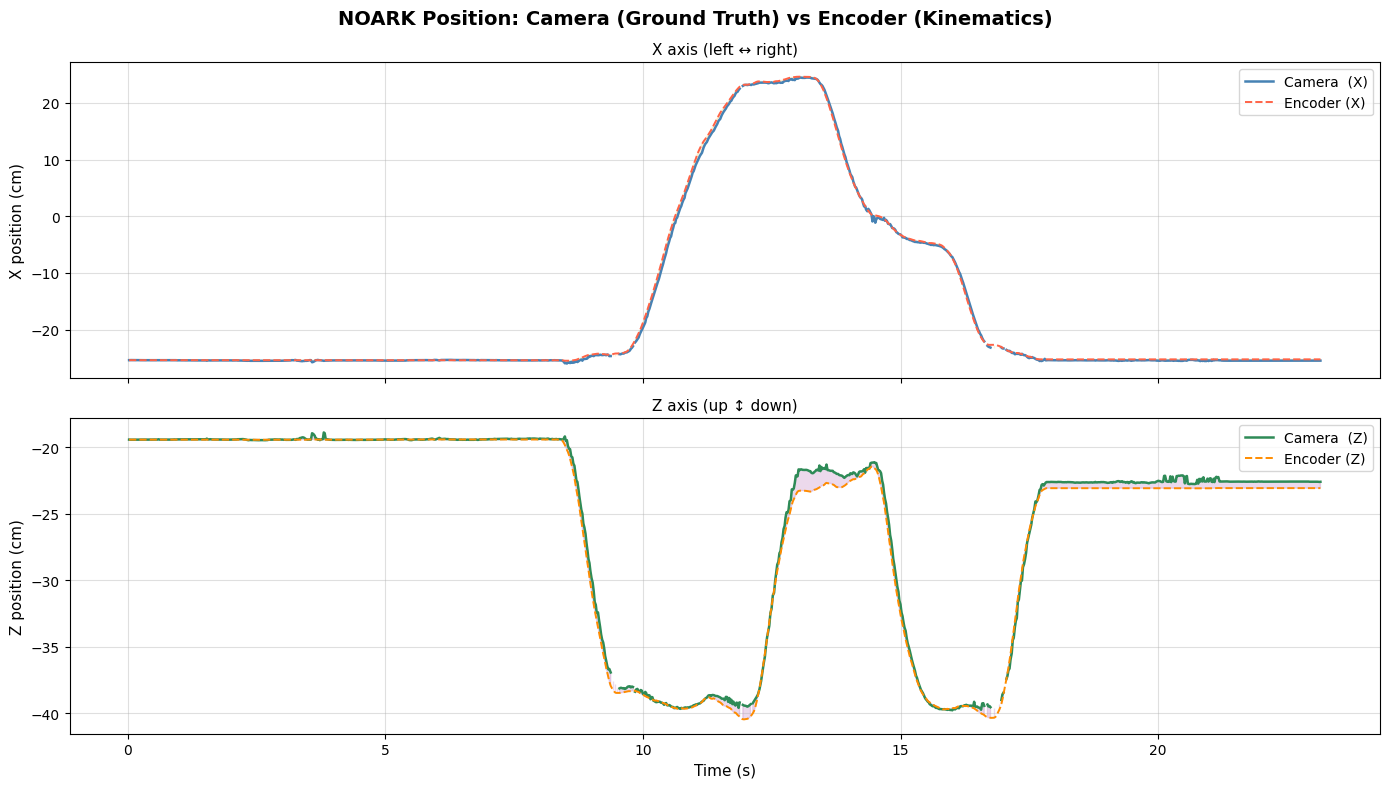

Saved: plot1_timeseries.png


In [16]:
# ── Step 7 — Timeseries Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Camera (Ground Truth) vs Encoder (Kinematics)", fontsize=14, fontweight='bold')

t = merged["t_sec"]

# ── X axis ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t, merged["x_cam_cm"], color="steelblue",  lw=1.8, label="Camera  (X)")
ax.plot(t, merged["x_enc_cm"], color="tomato",     lw=1.4, ls="--", label="Encoder (X)")
ax.fill_between(t, merged["x_cam_cm"], merged["x_enc_cm"], alpha=0.15, color="orange")
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

# ── Z axis ────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t, merged["z_cam_cm"], color="seagreen",   lw=1.8, label="Camera  (Z)")
ax.plot(t, merged["z_enc_cm"], color="darkorange", lw=1.4, ls="--", label="Encoder (Z)")
ax.fill_between(t, merged["z_cam_cm"], merged["z_enc_cm"], alpha=0.15, color="purple")
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot1_timeseries.png", dpi=150, bbox_inches="tight")
# plt.savefig("repo_root/vaideesh/Analysis/plot1_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_timeseries.png")

---
## Step 8 — Plot 2: 2D Trajectory + Error Magnitude

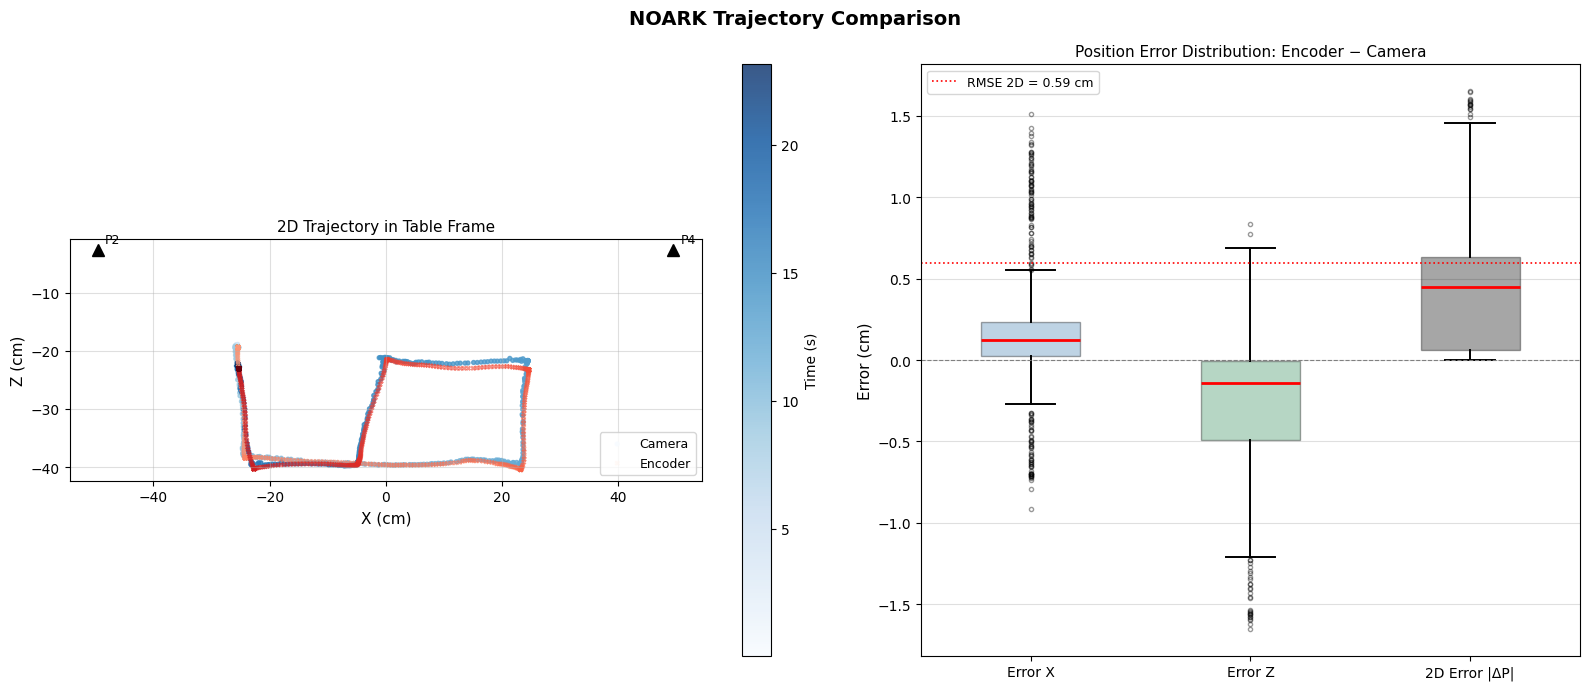

Saved: plot2_trajectory_error.png


In [17]:
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory Comparison", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory in X-Z table frame ─────────────────────────────
ax1 = fig.add_subplot(gs[0])
sc_cam = ax1.scatter(merged["x_cam_cm"], merged["z_cam_cm"],
                     c=merged["t_sec"], cmap="Blues", s=8, alpha=0.8, label="Camera")
sc_enc = ax1.scatter(merged["x_enc_cm"], merged["z_enc_cm"],
                     c=merged["t_sec"], cmap="Reds",  s=8, alpha=0.6, label="Encoder", marker="x")

for name, pt in [("P2", P2), ("P4", P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, "k^", ms=8)
    ax1.annotate(name, (pt[0]*100, pt[2]*100), textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.colorbar(sc_cam, ax=ax1, label="Time (s)")
ax1.set_xlabel("X (cm)", fontsize=11)
ax1.set_ylabel("Z (cm)", fontsize=11)
ax1.set_title("2D Trajectory in Table Frame", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_aspect("equal", adjustable="box")

# ── Right panel: Box plot of position errors ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])

# error_data  = [merged["err_x_cm"], merged["err_z_cm"], merged["err_2d_cm"]]
# boxplot — use valid numpy arrays, not merged columns
error_data = [err_x_valid, err_z_valid, err_2d_valid]
labels      = ["Error X", "Error Z", "2D Error |ΔP|"]

colors      = ["steelblue", "seagreen", "black"]

bp = ax2.boxplot(
    error_data,
    labels=labels,
    patch_artist=True,       # filled boxes
    notch=False,
    widths=0.45,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.4),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

# RMSE annotation on the 2D error box (3rd box)

# rmse_2d = np.sqrt((merged["err_2d_cm"]**2).mean())

# RMSE line — same
rmse_2d = np.sqrt((err_2d_valid**2).mean())
ax2.axhline(rmse_2d, color="red", lw=1.2, ls=":", label=f"RMSE 2D = {rmse_2d:.2f} cm")

ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.set_ylabel("Error (cm)", fontsize=11)
ax2.set_title("Position Error Distribution: Encoder − Camera", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis="y")

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot2_trajectory_error.png", dpi=150, bbox_inches="tight")
# plt.savefig("/home/sujith/Documents/NOARK_backbone/vaideesh/Analysis/plot2_trajectory_error.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_trajectory_error.png")

---
## Step 9 —  Save Merged Data to CSV

In [ ]:
out_cols = ["timestamp", "t_sec", "x_cam_cm", "z_cam_cm", "x_enc_cm", "z_enc_cm",
            "err_x_cm", "err_z_cm", "err_2d_cm"]
merged[out_cols].to_csv(repo_root / "vaideesh" / "Analysis" /"Recordings"/ "linear_t0.csv", index=False)
print("Saved: linear_t0.csv")
print(os.getcwd())

Saved: noark_comparison.csv
e:\Ragav\MS Bio Engineering\NOARK_backbone
